# GOLDEN 12_effective_topology

**Thesis section:** `sec:results:eff_topology`
**Provenance:** Ported from notebooks/037 Effective Topology Analysis.ipynb
**Data:** results/mas/final_dataset_new_system (*_fc configs only, N=4, T=15, W∈{1,2,5})
**Figures exported to:** thesis/plots/eff_topology/
  (fig1_topology_examples, fig2_accuracy_by_type, fig3_design_guideline)
**Status:** reproducible from committed data.

This is a GOLDEN notebook. It recomputes every number in `sec:results:eff_topology`
and exports the three figures. Numbers are printed in labelled blocks for manual copy
into the .tex. Where a recomputed value differs from the .tex, print MISMATCH.


In [1]:
import sys
sys.path.insert(0, '../..')

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy import stats as sp_stats

from src.metrics.dominance import _influence_graph
from src.viz.thesis_style import apply_style, W_COLORS, DS_COLORS, DS_LABELS, FIGSIZES

apply_style()

BASE   = Path('../..') / 'results' / 'mas' / 'final_dataset_new_system'
EXPORT = Path('../..') / 'thesis' / 'plots' / 'eff_topology'
EXPORT.mkdir(parents=True, exist_ok=True)

HUB_COLOR      = '#e67e22'
DEFAULT_COLOR  = '#3498db'
CORRECT_BORDER = '#27ae60'
DEFAULT_BORDER = '#95a5a6'
TYPE_COLORS = {
    'flat':       '#95a5a6',
    'hub':        '#3498db',
    'two-hub':    '#9b59b6',
    'star':       '#e67e22',
    'degenerate': '#ecf0f1',
}
TYPE_ORDER = ['flat', 'hub', 'two-hub', 'star']


/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def topology_type(p_sorted, N):
    p0 = p_sorted[0]
    p1 = p_sorted[1] if N > 1 else 0.0
    if p0 >= 0.75:
        return 'star'
    if p0 < 0.60 and p1 > 0 and p1 / p0 > 0.65:
        return 'two-hub'
    if p0 >= 0.45:
        return 'hub'
    return 'flat'


records = []

for f in sorted(BASE.glob('*_fc/*.json')):
    d       = json.loads(f.read_text())
    ds      = d['dataset']
    W_param = d['W']
    qid     = d['question_id']
    gt      = d['ground_truth']

    for rep_idx, rep in enumerate(d['repetitions']):
        traj  = rep['trajectory']
        N     = len(traj[0]['phase_b'])
        W_mat = _influence_graph(rep)
        s     = W_mat.sum(axis=1)
        total = float(s.sum())

        if total > 0:
            p        = s / total
            p_sorted = np.sort(p)[::-1]
            ttype    = topology_type(p_sorted, N)
        else:
            p_sorted = np.full(N, 1.0 / N)
            ttype    = 'degenerate'

        hub_idx    = int(np.argmax(s))
        init_votes = [traj[0]['phase_b'][ag]['vote'] for ag in range(N)]
        n_unique   = len(set(init_votes))
        split      = tuple(sorted(Counter(init_votes).values(), reverse=True))

        records.append({
            'dataset':          ds,
            'W_param':          W_param,
            'qid':              qid,
            'rep_idx':          rep_idx,
            'correct':          int(rep['correct']),
            'total_influence':  total,
            'hub_frac':         float(p_sorted[0]),
            'second_frac':      float(p_sorted[1]) if N > 1 else 0.0,
            'ttype':            ttype,
            'hub_init_correct': int(init_votes[hub_idx] == gt) if total > 0 else None,
            'n_unique':         n_unique,
            'split':            str(split),
            'W_mat':            W_mat.tolist(),
            'init_votes':       init_votes,
            'gt':               gt,
        })

df       = pd.DataFrame(records)
df_valid = df[df['total_influence'] > 0].copy()

print(f'FC reps: {len(df):,}  valid (>=1 flip): {len(df_valid):,}')


FC reps: 15,000  valid (>=1 flip): 12,506


In [3]:
def draw_network(W_mat, ax, title='', correct=None, gt=None, init_votes=None,
                  show_legend=False):
    W     = np.array(W_mat, dtype=float)
    N     = len(W)
    s     = W.sum(axis=1)
    total = s.sum()

    angles = [np.pi / 2 + 2 * np.pi * i / N for i in range(N)]
    pos    = {i: (np.cos(angles[i]), np.sin(angles[i])) for i in range(N)}

    hub   = int(np.argmax(s))
    W_max = W.max() if W.max() > 0 else 1.0

    G = nx.DiGraph()
    G.add_nodes_from(range(N))
    for i in range(N):
        for j in range(N):
            if i != j and W[i, j] > 1e-9:
                G.add_edge(i, j, weight=W[i, j])

    node_colors   = [HUB_COLOR if (total > 0 and i == hub) else DEFAULT_COLOR
                     for i in range(N)]
    border_colors = [CORRECT_BORDER if (init_votes is not None and gt is not None
                                         and init_votes[i] == gt)
                     else DEFAULT_BORDER for i in range(N)]
    node_sizes    = [400 + 900 * (s[i] / total if total > 0 else 1 / N)
                     for i in range(N)]

    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(range(N)),
                           node_color=node_colors, node_size=node_sizes,
                           edgecolors=border_colors, linewidths=3)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white',
                            font_size=10, font_weight='bold')

    edges = list(G.edges())
    if edges:
        widths = [3.5 * G[u][v]['weight'] / W_max for u, v in edges]
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, width=widths,
                               edge_color='#2c3e50', alpha=0.65, arrows=True,
                               arrowsize=14, connectionstyle='arc3,rad=0.15',
                               min_source_margin=20, min_target_margin=20)

    hub_pct = 100 * s[hub] / total if total > 0 else 25.0
    p_s     = np.sort(s / total if total > 0 else np.full(N, 1 / N))[::-1]
    ttype   = topology_type(p_s, N) if total > 0 else 'degenerate'
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.65, 1.65)
    ax.axis('off')
    return ttype, hub_pct


## Figure 1 — Topology-type examples

One archetypal run per type, arranged in a 2×2 grid.
Arrow width ∝ influence weight; **orange fill** = hub (most influential agent);
**green border** = agent started with the correct answer.


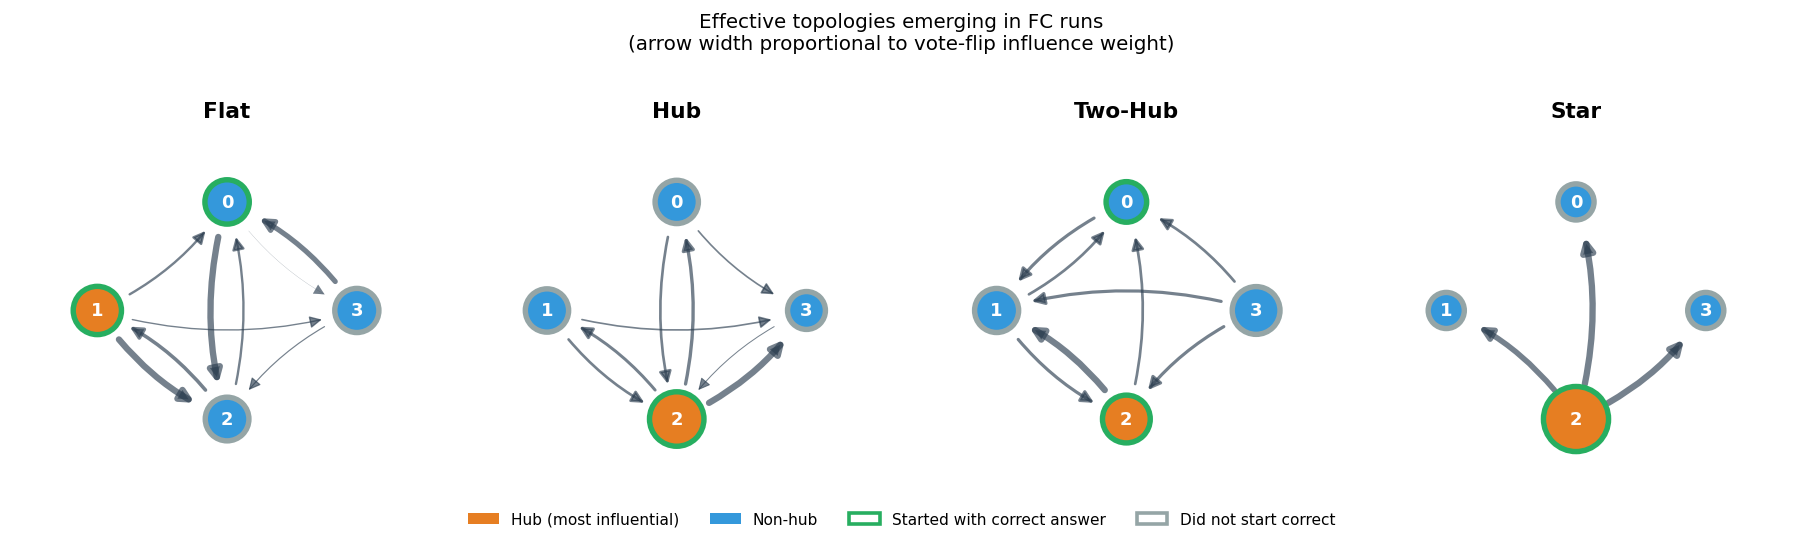

Saved fig1_topology_examples


In [4]:
def pick_exemplar(df_valid, ttype, target_hub_frac=None, target_balance=None):
    sub = df_valid[df_valid['ttype'] == ttype]
    if ttype == 'flat':
        return sub.nsmallest(20, 'hub_frac').iloc[4]
    if ttype == 'hub':
        target = sub['hub_frac'].quantile(0.5)
        return sub.iloc[(sub['hub_frac'] - target).abs().argsort().iloc[0]]
    if ttype == 'two-hub':
        sub = sub.copy()
        sub['balance'] = sub['second_frac'] / sub['hub_frac']
        return sub.nlargest(10, 'balance').iloc[3]
    if ttype == 'star':
        return sub.nlargest(15, 'hub_frac').iloc[5]


TYPE_LABELS = {
    'flat':    'Flat',
    'hub':     'Hub',
    'two-hub': 'Two-Hub',
    'star':    'Star',
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))

for ax, ttype in zip(axes, TYPE_ORDER):
    row   = pick_exemplar(df_valid, ttype)
    s_loc = np.array(row['W_mat']).sum(axis=1)
    tot   = s_loc.sum()
    p_s   = np.sort(s_loc / tot)[::-1]
    hub_pct = 100 * p_s[0]
    draw_network(row['W_mat'], ax,
                 title=TYPE_LABELS[ttype],
                 correct=row['correct'],
                 gt=row['gt'],
                 init_votes=row['init_votes'])
    ax.set_xlabel(f'hub share: {hub_pct:.0f}%', fontsize=9, labelpad=2)

legend_elements = [
    mpatches.Patch(facecolor=HUB_COLOR,     label='Hub (most influential)'),
    mpatches.Patch(facecolor=DEFAULT_COLOR, label='Non-hub'),
    mpatches.Patch(facecolor='white', edgecolor=CORRECT_BORDER, linewidth=2,
                   label='Started with correct answer'),
    mpatches.Patch(facecolor='white', edgecolor=DEFAULT_BORDER, linewidth=2,
                   label='Did not start correct'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=8.5, bbox_to_anchor=(0.5, -0.06), frameon=False)

plt.suptitle('Effective topologies emerging in FC runs\n'
             '(arrow width proportional to vote-flip influence weight)',
             fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(EXPORT / 'fig1_topology_examples.pdf', bbox_inches='tight')
fig.savefig(EXPORT / 'fig1_topology_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_topology_examples')


## Figure 2 — Accuracy by effective topology type

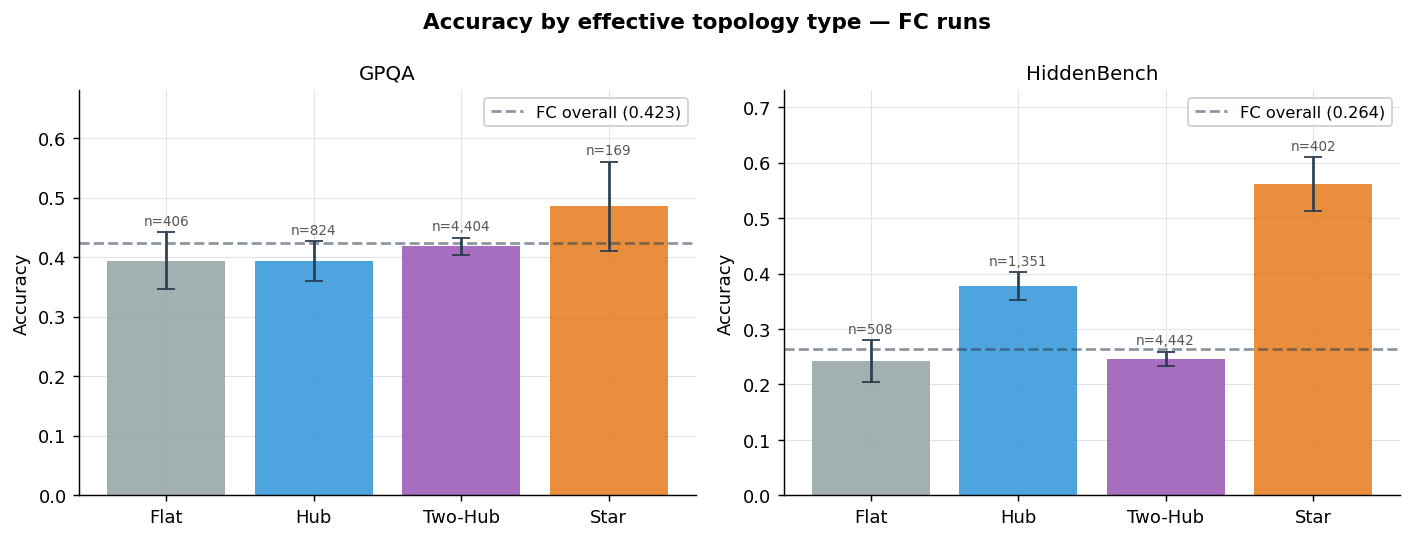

Saved fig2_accuracy_by_type


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    sub   = df[df['dataset'] == ds]
    means, cis, ns = [], [], []
    for t in TYPE_ORDER:
        vals = sub[sub['ttype'] == t]['correct'].values
        if len(vals) == 0:
            means.append(np.nan); cis.append(0); ns.append(0)
            continue
        m  = vals.mean()
        ci = 1.96 * np.sqrt(m * (1 - m) / len(vals))
        means.append(m); cis.append(ci); ns.append(len(vals))

    x      = np.arange(len(TYPE_ORDER))
    colors = [TYPE_COLORS[t] for t in TYPE_ORDER]
    ax.bar(x, means, yerr=cis, capsize=5, color=colors, alpha=0.88,
           error_kw=dict(lw=1.5, ecolor='#2c3e50'))

    for xi, (m, ci, n) in enumerate(zip(means, cis, ns)):
        if not np.isnan(m):
            ax.text(xi, m + ci + 0.012, f'n={n:,}', ha='center', fontsize=7.5,
                    color='#555')

    overall = sub['correct'].mean()
    ax.axhline(overall, ls='--', lw=1.5, color='#2c3e50', alpha=0.55,
               label=f'FC overall ({overall:.3f})')

    ax.set_xticks(x)
    ax.set_xticklabels([TYPE_LABELS[t] for t in TYPE_ORDER], fontsize=10)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_title(DS_LABELS[ds], fontsize=11)
    ax.set_ylim(0, min(1.0, max(means) + max(cis) + 0.12))
    ax.legend(fontsize=9)

fig.suptitle('Accuracy by effective topology type — FC runs', fontsize=12,
             fontweight='bold')
plt.tight_layout()
fig.savefig(EXPORT / 'fig2_accuracy_by_type.pdf', bbox_inches='tight')
fig.savefig(EXPORT / 'fig2_accuracy_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_accuracy_by_type')


## Figure 3 — Design guideline: initial vote diversity drives star formation

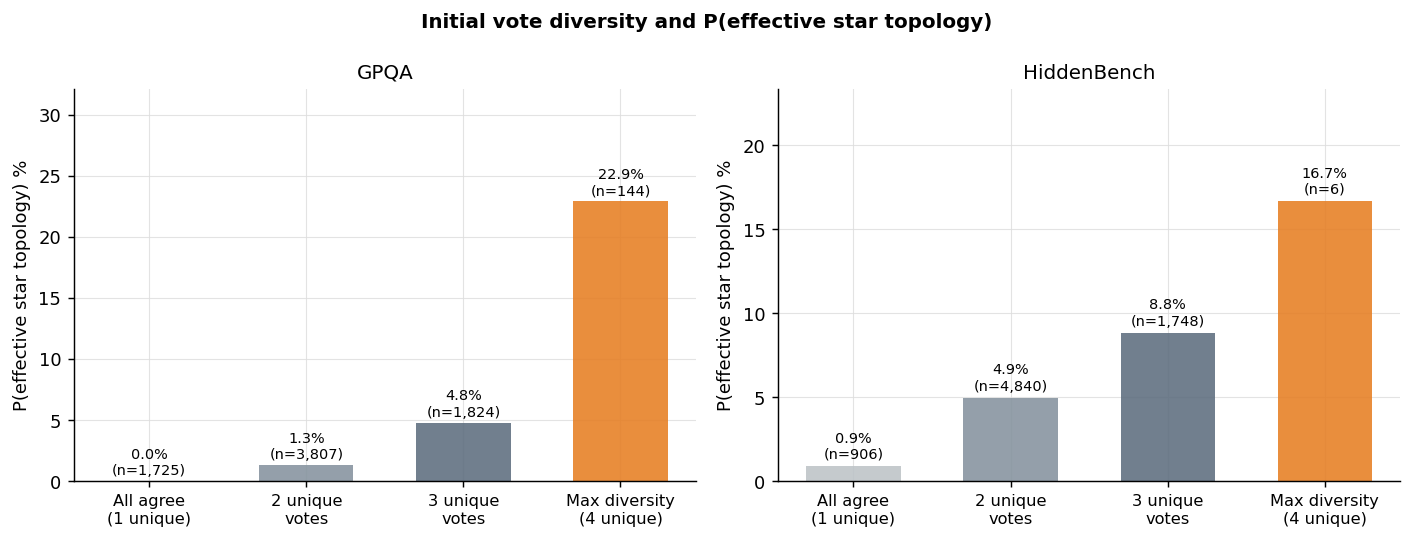

Saved fig3_design_guideline


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

diversity_labels = {1: 'All agree\n(1 unique)', 2: '2 unique\nvotes',
                    3: '3 unique\nvotes', 4: 'Max diversity\n(4 unique)'}

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    sub     = df[df['dataset'] == ds]
    nu_vals = sorted(sub['n_unique'].unique())
    p_star  = [100 * (sub[sub['n_unique'] == nu]['ttype'] == 'star').mean()
               for nu in nu_vals]
    ns      = [len(sub[sub['n_unique'] == nu]) for nu in nu_vals]
    colors  = ['#bdc3c7', '#85929e', '#5d6d7e', TYPE_COLORS['star']][:len(nu_vals)]

    bars = ax.bar(range(len(nu_vals)), p_star, color=colors, alpha=0.88, width=0.6)

    for xi, (v, n) in enumerate(zip(p_star, ns)):
        ax.text(xi, v + 0.3, f'{v:.1f}%\n(n={n:,})', ha='center',
                fontsize=8, va='bottom')

    ax.set_xticks(range(len(nu_vals)))
    ax.set_xticklabels([diversity_labels.get(nu, str(nu)) for nu in nu_vals],
                       fontsize=9)
    ax.set_ylabel('P(effective star topology) %', fontsize=10)
    ax.set_title(DS_LABELS[ds], fontsize=11)
    ax.set_ylim(0, max(p_star) * 1.4)

fig.suptitle('Initial vote diversity and P(effective star topology)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
fig.savefig(EXPORT / 'fig3_design_guideline.pdf', bbox_inches='tight')
fig.savefig(EXPORT / 'fig3_design_guideline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_design_guideline')


## Key numbers (copy into thesis .tex)

In [7]:
print('=' * 65)
print('--- sec:results:eff_topology: topology type distribution ---')
for ds in ['gpqa', 'hiddenbench']:
    sub = df[df['dataset'] == ds]
    print(f'  {DS_LABELS[ds]}  (n={len(sub):,}):')
    for t in ['flat', 'hub', 'two-hub', 'star', 'degenerate']:
        pct = 100 * (sub['ttype'] == t).mean()
        acc = sub[sub['ttype'] == t]['correct'].mean()
        print(f'    {t:12s}: {pct:5.1f}%  acc={acc:.3f}')

print()
print('--- sec:results:eff_topology: accuracy by type ---')
for ds in ['gpqa', 'hiddenbench']:
    sub = df[df['dataset'] == ds]
    overall = sub['correct'].mean()
    star_acc = sub[sub['ttype'] == 'star']['correct'].mean()
    twohub_acc = sub[sub['ttype'] == 'two-hub']['correct'].mean()
    print(f'  {DS_LABELS[ds]}: overall={overall:.3f}  star={star_acc:.3f}'
          f'  two-hub={twohub_acc:.3f}')

print()
print('--- sec:results:eff_topology: hub selection (correct present at t=0) ---')
for ds in ['gpqa', 'hiddenbench']:
    sub = df_valid[df_valid['dataset'] == ds].copy()
    sub['correct_present'] = sub.apply(lambda r: r['gt'] in r['init_votes'], axis=1)
    present = sub[sub['correct_present']]
    for t in ['hub', 'two-hub', 'star']:
        rows = present[present['ttype'] == t]
        if len(rows):
            rate = rows['hub_init_correct'].mean()
            print(f'  {DS_LABELS[ds]} {t}: hub_init_correct={rate:.3f}'
                  f'  n={len(rows)}  (chance=0.25)')

print()
print('--- sec:results:eff_topology: star winner-take-all ---')
for ds in ['gpqa', 'hiddenbench']:
    star = df_valid[(df_valid['dataset'] == ds) & (df_valid['ttype'] == 'star')]
    c1   = star[star['hub_init_correct'] == 1]['correct'].mean()
    c0   = star[star['hub_init_correct'] == 0]['correct'].mean()
    print(f'  {DS_LABELS[ds]}: hub_correct->acc={c1:.3f}  hub_wrong->acc={c0:.3f}')

print()
print('--- sec:results:eff_topology: design guideline (P(star) by n_unique) ---')
for nu in sorted(df['n_unique'].unique()):
    sub = df[df['n_unique'] == nu]
    ps  = 100 * (sub['ttype'] == 'star').mean()
    print(f'  n_unique={nu}: n={len(sub):,}  P(star)={ps:.1f}%')

print()
print('--- sec:results:eff_topology: (2,2) two-hub faction battle ---')
th22 = df_valid[(df_valid['ttype'] == 'two-hub') & (df_valid['split'] == '(2, 2)')]
th22_cp = th22.copy()
th22_cp['correct_present'] = th22_cp.apply(
    lambda r: r['gt'] in r['init_votes'], axis=1)
c2 = th22_cp[th22_cp.apply(
    lambda r: sum(v == r['gt'] for v in r['init_votes']) == 2, axis=1)]['correct'].mean()
c0 = th22_cp[th22_cp.apply(
    lambda r: sum(v == r['gt'] for v in r['init_votes']) == 0, axis=1)]['correct'].mean()
print(f'  Two-hub (2,2) overall acc: {th22["correct"].mean():.3f}  n={len(th22):,}')
print(f'  Correct faction present: acc={c2:.3f}')
print(f'  No correct at start:     acc={c0:.3f}')

print()
print('--- sec:results:eff_topology: nominal star comparison ---')
star_rows = []
for f in sorted(BASE.glob('*_star/*.json')):
    d  = json.loads(f.read_text())
    gt = d['ground_truth']
    ds = d['dataset']
    for rep in d['repetitions']:
        traj     = rep['trajectory']
        N        = len(traj[0]['phase_b'])
        topology = rep['topology']
        in_deg   = [sum(topology[j][i] for j in range(N) if j != i) for i in range(N)]
        center   = int(np.argmax(in_deg))
        init_votes = [traj[0]['phase_b'][i]['vote'] for i in range(N)]
        star_rows.append({
            'dataset':         ds,
            'correct':         int(rep['correct']),
            'center_correct':  int(init_votes[center] == gt),
        })
df_star = pd.DataFrame(star_rows)
for ds in ['gpqa', 'hiddenbench']:
    sub = df_star[df_star['dataset'] == ds]
    p_c = sub['center_correct'].mean()
    print(f'  {DS_LABELS[ds]} nominal star: P(center started correct)={p_c:.3f}')

print('=' * 65)


--- sec:results:eff_topology: topology type distribution ---
  GPQA  (n=7,500):
    flat        :   5.4%  acc=0.394
    hub         :  11.0%  acc=0.393
    two-hub     :  58.7%  acc=0.418
    star        :   2.3%  acc=0.485
    degenerate  :  22.6%  acc=0.450
  HiddenBench  (n=7,500):
    flat        :   6.8%  acc=0.242
    hub         :  18.0%  acc=0.377
    two-hub     :  59.2%  acc=0.247
    star        :   5.4%  acc=0.562
    degenerate  :  10.6%  acc=0.029

--- sec:results:eff_topology: accuracy by type ---
  GPQA: overall=0.423  star=0.485  two-hub=0.418
  HiddenBench: overall=0.264  star=0.562  two-hub=0.247

--- sec:results:eff_topology: hub selection (correct present at t=0) ---
  GPQA hub: hub_init_correct=0.412  n=672  (chance=0.25)
  GPQA two-hub: hub_init_correct=0.524  n=3422  (chance=0.25)
  GPQA star: hub_init_correct=0.545  n=145  (chance=0.25)
  HiddenBench hub: hub_init_correct=0.714  n=755  (chance=0.25)
  HiddenBench two-hub: hub_init_correct=0.418  n=2161  (chance

  GPQA nominal star: P(center started correct)=0.384
  HiddenBench nominal star: P(center started correct)=0.150
